# K-Nearest Neighbors Classifier

This notebook trains a **KNN** classifier on the Breast Cancer Wisconsin dataset and tunes `n_neighbors` (K) with cross-validation. Workflow:

1. Load data and split into train/test
2. Scale features (KNN is distance-based, so scaling matters a lot)
3. Fit a quick baseline model (K=5) just to sanity-check the pipeline
4. Tune K with 5-fold cross-validation (accuracy **and** ROC-AUC)
5. Refit a final model using the best K and evaluate it properly on the held-out test set
6. Visualize K vs. CV score, the confusion matrix, and the ROC curve

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

## 2. Load data
30 numeric features, binary target (`0` = malignant, `1` = benign).

In [ ]:
datas = load_breast_cancer()

In [ ]:
X = pd.DataFrame(
    datas.data,
    columns=datas.feature_names
)
y = datas.target
X.shape, y.shape

((569, 30), (569,))

## 3. Train / test split
We hold out 20% of the data for the final evaluation in Section 6. The K search in Section 5 uses the full `X`/`y` only to *select* K via cross-validation — it never touches the reserved test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Scale features
KNN relies on distances between points, so unscaled features (e.g. `area` in the hundreds vs. `smoothness` around 0.1) would dominate the distance calculation. We fit the scaler on the train split only, then apply it to test.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Baseline model (K=5)
Before tuning anything, fit a quick baseline with an arbitrary K=5 just to confirm the pipeline works end-to-end. **This is not the final model** — we'll tune K properly next and refit.

In [ ]:
baseline_model = KNeighborsClassifier(n_neighbors=5)
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)

print("Baseline (K=5) Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Baseline (K=5) Precision:", round(precision_score(y_test, y_pred_baseline), 4))
print("Baseline (K=5) Recall   :", round(recall_score(y_test, y_pred_baseline), 4))
print("Baseline (K=5) F1 Score :", round(f1_score(y_test, y_pred_baseline), 4))

Baseline (K=5) Accuracy : 0.9561
Baseline (K=5) Precision: 0.9589
Baseline (K=5) Recall   : 0.9722
Baseline (K=5) F1 Score : 0.9655


## 6. Tune K with cross-validation
Sweep odd values of K from 1 to 29 (odd K avoids tied votes in binary classification). We track both **accuracy** and **ROC-AUC** across folds; accuracy is used to pick the best K, and ROC-AUC is shown alongside for a fuller picture, since accuracy alone can be misleading on imbalanced classes.

In [ ]:
k_values = list(range(1, 31, 2))

scores = {}
scores_auc = {}

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])

    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    scores[k] = float(round(cv_scores.mean(), 4))

    cv_scores_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    scores_auc[k] = float(round(cv_scores_auc.mean(), 4))

scores

{1: 0.9543,
 3: 0.9595,
 5: 0.9649,
 7: 0.9701,
 9: 0.9666,
 11: 0.9649,
 13: 0.9666,
 15: 0.9614,
 17: 0.9596,
 19: 0.9561,
 21: 0.9561,
 23: 0.9508,
 25: 0.9526,
 27: 0.9526,
 29: 0.9543}

In [ ]:
scores_auc

{1: 0.95,
 3: 0.9844,
 5: 0.9916,
 7: 0.9908,
 9: 0.9923,
 11: 0.9917,
 13: 0.992,
 15: 0.9927,
 17: 0.9918,
 19: 0.9914,
 21: 0.9911,
 23: 0.9905,
 25: 0.9906,
 27: 0.9911,
 29: 0.9908}

In [ ]:
best_k = max(scores, key=scores.get)

print("Best K:", best_k)
print("Best CV Accuracy:", scores[best_k])
print("CV ROC-AUC at that K:", scores_auc[best_k])

Best K: 7
Best CV Accuracy: 0.9701
CV ROC-AUC at that K: 0.9908


### K vs. CV score
The best K (by accuracy) is highlighted with a red marker.

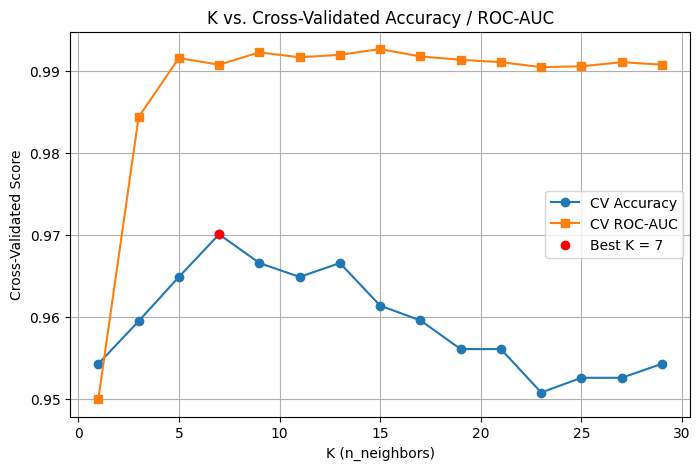

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(list(scores.keys()), list(scores.values()), marker='o', label='CV Accuracy')
ax1.plot(list(scores_auc.keys()), list(scores_auc.values()), marker='s', label='CV ROC-AUC')
ax1.scatter([best_k], [scores[best_k]], color='red', zorder=5, label=f'Best K = {best_k}')

ax1.set_xlabel('K (n_neighbors)')
ax1.set_ylabel('Cross-Validated Score')
ax1.set_title('K vs. Cross-Validated Accuracy / ROC-AUC')
ax1.legend()
ax1.grid(True)

plt.show()

## 7. Refit the final model with the best K and evaluate on the test set
This is the model whose numbers should actually be reported — the baseline in Section 5 used an arbitrary K and is superseded by this one.

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"Final model (K={best_k}) test-set metrics")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 4))

Final model (K=7) test-set metrics
Accuracy : 0.9737
Precision: 0.96
Recall   : 1.0
F1 Score : 0.9796
ROC-AUC  : 0.9884


### Confusion matrix

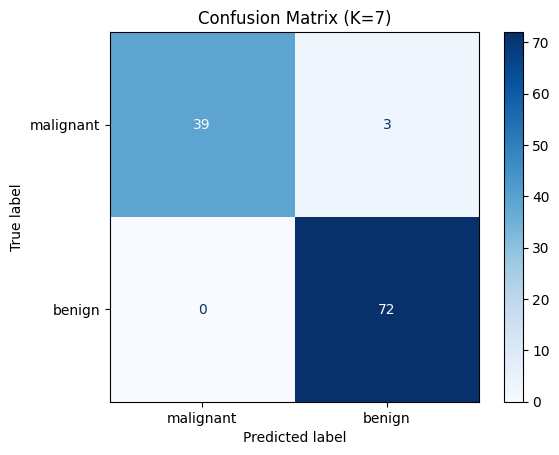

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=datas.target_names)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (K={best_k})')
plt.show()

### ROC curve

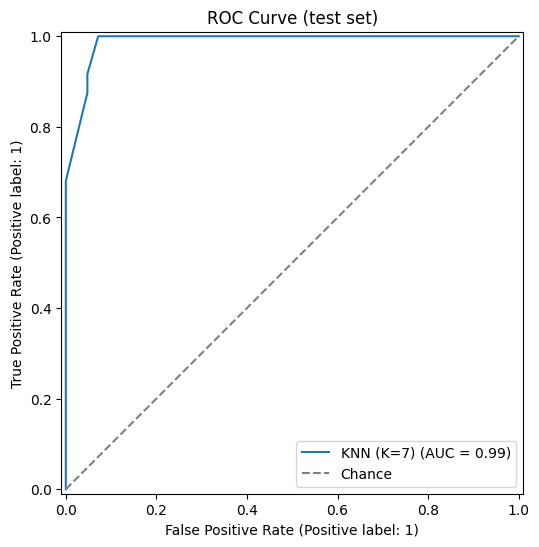

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(final_model, X_test_scaled, y_test, ax=ax, name=f'KNN (K={best_k})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve (test set)')
ax.legend()
plt.show()

## 8. Summary
- The K=5 baseline was just a sanity check, not a tuned model — it's easy to accidentally report its numbers as final, so this notebook now clearly separates baseline vs. tuned results.
- Cross-validation selected **K = best_k** (see printed value above) based on accuracy; ROC-AUC at that K is also reported since accuracy alone can hide class imbalance issues.
- The final model is refit on the train split with the selected K and scored only once on the held-out test set (accuracy, precision, recall, F1, ROC-AUC, confusion matrix, ROC curve) — avoiding the leakage that would come from tuning K directly against the test set.